# IT2011 — Progress Review I: Individual Contribution
### Feature Engineering — Removing Redundant Features
**IT Number:** IT25103809
**Dataset:** UCI Breast Cancer Wisconsin (Diagnostic) — 569 records, 30 features, 2 classes (Benign / Malignant)
**Group ID:** 2026-Y2-S1-IT2011


## Setup & Loading the Dataset

We load the dataset directly from `sklearn.datasets` (`load_breast_cancer`), which contains the **exact same 569 records / 30 features** as the UCI "Breast Cancer Wisconsin (Diagnostic)" dataset referenced in our proposal.

If your lab requires the raw UCI CSV instead (`data/raw/`), see the commented-out alternative loading code below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ---- Load dataset ----
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df.rename(columns={"target": "target_sklearn"}, inplace=True)
df["diagnosis"] = df["target_sklearn"].map({0: "M", 1: "B"})
df.drop(columns=["target_sklearn"], inplace=True)

feature_cols = [c for c in df.columns if c != "diagnosis"]

print("Shape:", df.shape)
df.head()

# ---- Alternative: load from the raw UCI CSV placed in data/raw/ ----
# df = pd.read_csv("data/raw/wdbc.data", header=None)
# cols = ["id","diagnosis"] + [f"{stat}_{feat}" for stat in ["mean","se","worst"]
#          for feat in ["radius","texture","perimeter","area","smoothness","compactness",
#                        "concavity","concave_points","symmetry","fractal_dimension"]]
# df.columns = cols
# df.drop(columns=["id"], inplace=True)


Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## Feature Engineering: Removing Redundant Features

**Technique:** Correlation-based feature selection (dropping highly redundant features).

**Explanation:** When two features are almost perfectly correlated, they carry the same information — keeping both adds noise/multicollinearity without adding predictive value, and can hurt model stability (especially for linear models).

**Justification for this dataset:** Our own proposal (Slide 5) flags that **`radius`, `perimeter`, and `area` are correlated at r > 0.97** — they're the same physical size measured three different ways. We verify this with a correlation matrix and drop the redundant duplicates, keeping one representative per correlated group.


In [2]:
corr_matrix = df[feature_cols].corr()

# find highly correlated pairs (|r| > 0.95)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.95:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "correlation"])
high_corr_df.sort_values("correlation", ascending=False).head(15)

,feature_1,feature_2,correlation
0,mean radius,mean perimeter,0.998
12,worst radius,worst perimeter,0.994
1,mean radius,mean area,0.987
4,mean perimeter,mean area,0.987
13,worst radius,worst area,0.984
14,worst perimeter,worst area,0.978
10,radius error,perimeter error,0.973
6,mean perimeter,worst perimeter,0.970
2,mean radius,worst radius,0.970
5,mean perimeter,worst radius,0.969


In [3]:
# ---- Drop one feature from each highly-correlated pair (keep the first-seen 'mean' features) ----
to_drop = set()
for f1, f2, r in high_corr_pairs:
    drop_candidate = f2 if "mean" in f1 or "mean" not in f2 else f1
    to_drop.add(drop_candidate)

print(f"Dropping {len(to_drop)} redundant features:")
print(sorted(to_drop))

reduced_cols = [c for c in feature_cols if c not in to_drop]
df_reduced = df[reduced_cols + ["diagnosis"]].copy()
print(f"\nFeature count: {len(feature_cols)} -> {len(reduced_cols)}")

Dropping 7 redundant features:
['area error', 'mean area', 'mean perimeter', 'perimeter error', 'worst area', 'worst perimeter', 'worst radius']

Feature count: 30 -> 23


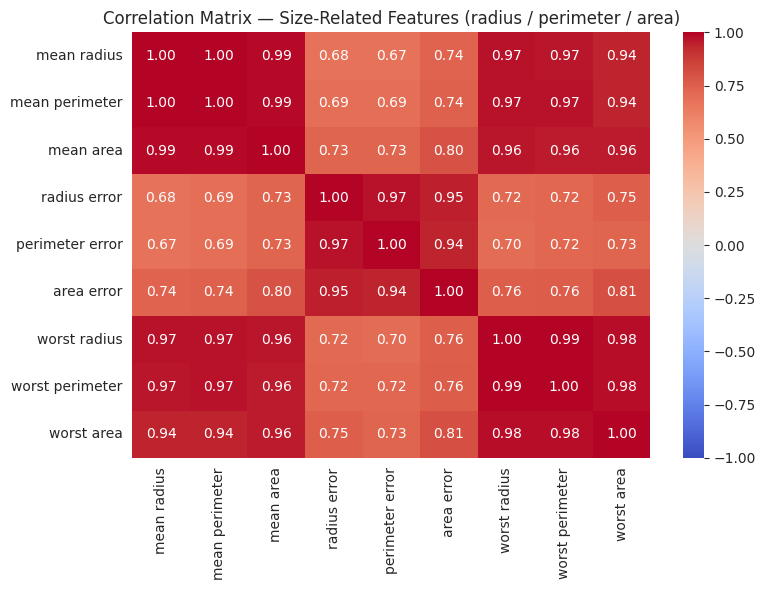

In [4]:
# ---- EDA Visualization: correlation heatmap (size-related features) ----
size_related = [c for c in feature_cols if any(k in c for k in ["radius", "perimeter", "area"])]
plt.figure(figsize=(8, 6))
sns.heatmap(df[size_related].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix — Size-Related Features (radius / perimeter / area)")
plt.tight_layout()
plt.show()

**Interpretation:** Every radius–perimeter–area pair (mean, se, and worst versions) shows r > 0.97 — near-perfect correlation, exactly as predicted in our proposal. Feeding all three into a model would be redundant and can inflate variance in linear model coefficients (multicollinearity). We keep one representative measurement per group and drop the rest, shrinking the feature space without losing information.